<a href="https://colab.research.google.com/github/sipark109/26MLseminar/blob/logistic/logistic_regression_ffinal_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# logistic regression : Titanic 생존률 분석하기

사용할 데이터 : https://www.kaggle.com/datasets/heptapod/titanic

++ naive bayes로도 해보기


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("train_and_test2.csv")

## 데이터 확인

In [ ]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,...,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1307.000000,1309.0,1309.0,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.294882,0.0,0.0,1.492731,0.0,0.0,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.837836,0.0,0.0,0.814626,0.0,0.0,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.000000,0.0,0.0,1.000000,0.0,0.0,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000


## 데이터 전처리

In [ ]:
# 필요없는 input들 제거하기
# zero로 시작하는 열: 확인해본 결과 불필요
# Passengerid: 승객 고유번호라 예측에 의미 없음
# Embarked: 승선항구, 객실등급이랑 겹쳐서 의미없음
df = df.loc[:, ~df.columns.str.contains("zero")]
df = df.drop(columns=["Passengerid", "Embarked"])


In [ ]:
df.head()

,Age,Fare,Sex,sibsp,Parch,Pclass,2urvived
0,22.0,7.2500,0,1,0,3,0
1,38.0,71.2833,1,1,0,1,1
2,26.0,7.9250,1,0,0,3,1
3,35.0,53.1000,1,1,0,1,1
4,35.0,8.0500,0,0,0,3,0


In [ ]:
df.isnull().sum() #결측치 확인

,0
Age,0
Fare,0
Sex,0
sibsp,0
Parch,0
Pclass,0
2urvived,0


## 학습진행

### x / y 분리

y는 생존여부(2urvived)

x는
* Age(나이)
* Fare(운임비)
* Sex(성별)
* sibsp(동승객- 형제자매 및 배우자)
* Parch(동승객- 부모 및 자녀)
* Pclass(객실등급)


In [ ]:
print(df.columns)
X = df.drop("2urvived", axis=1)

y = df["2urvived"] # 데이터셋에서 x,y분리


Index(['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', '2urvived'], dtype='object')


### training / test data set 분리

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)




###데이터 표준화 해주기



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## logistic regression

threshold = 0.5

learning rate=0.0001

interation= 1000

In [ ]:
##logistic regression 구현
class LogisticRegression:
    #learing_rate 처음에 0.01 했는데 계속 overflow-> 더내리기
    def __init__(self, learning_rate=0.0001, n_iteration=1000):
        self.learning_rate = learning_rate
        self.n_iteration = n_iteration
        self.weight = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weight = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iteration):

            linear_model = np.dot(X, self.weight) + self.bias
            y_predicted = self.sigmoid(linear_model)
            ##gradient descent 구하기
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)
            ## 오차를 줄이도록 가중치를 계속 수정하기
            self.weight -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):

        linear_model = np.dot(X, self.weight) + self.bias
        y_predicted = self.sigmoid(linear_model)

        y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]

        return np.array(y_predicted_cls)

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weight) + self.bias
        return self.sigmoid(linear_model)  # 0~1 확률값 그대로 반환

## 정확도 구하기
def accuracy(y_true, y_pred):
    correct = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
    return correct / len(y_true)

In [ ]:
model = LogisticRegression(
    learning_rate=0.0001,
    n_iteration=1000
)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Accuracy:",accuracy(y_test,y_pred))

Accuracy: 0.7290076335877863


## logistic regression 합습 결과

confusion matrix


---



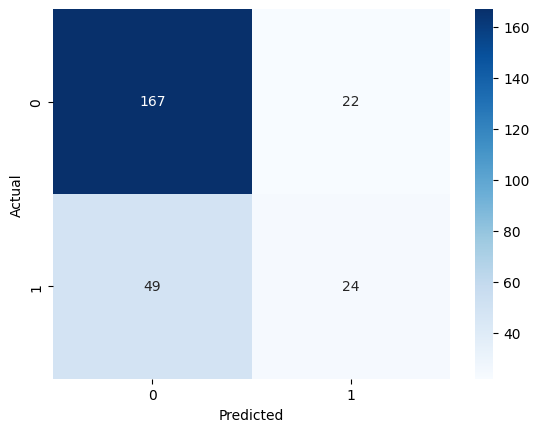

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

precision / recall / f1-score

---

class 1(생존)의 precision=0.52, recall=0.33으로 낮음 → 생존자를 잘 못 잡아내는 모델


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.88      0.82       189
           1       0.52      0.33      0.40        73

    accuracy                           0.73       262
   macro avg       0.65      0.61      0.61       262
weighted avg       0.70      0.73      0.71       262



결과정리

---

accuracy(0.73)는 괜찮아 보이지만, 생존자(class 1) 예측 성능은 낮은 편


개선방안

---

class 1의 recall을 높이는 방향으로 개선 필요


# Naive Bayes

$$P(y|X) = \frac{P(X|y) \cdot P(y)}{P(X)}$$
P(y): 생존여부

X: 나이,성별,요금 등


In [ ]:
nb = GaussianNB()
# 정규분포를 따른다고 가정
nb.fit(X_train, y_train)

GaussianNB()

In [ ]:
pred = nb.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, pred))

Accuracy : 0.7480916030534351


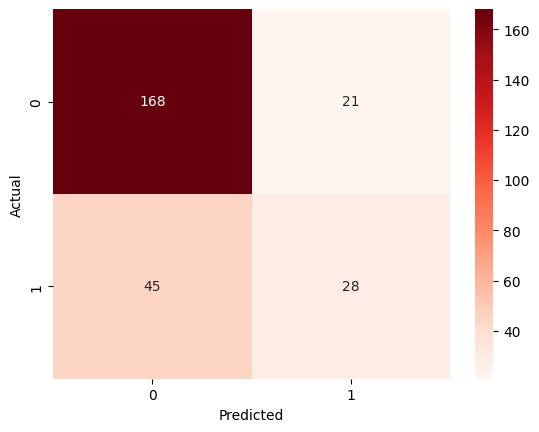

In [ ]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="Reds")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       189
           1       0.57      0.38      0.46        73

    accuracy                           0.75       262
   macro avg       0.68      0.64      0.65       262
weighted avg       0.73      0.75      0.73       262



ROC curve : threshold 0~1까지 바꾸면서 TPR(recall)이랑 FPR 변화 보여줌 -> 왼쪽위에 가까워질수록 좋음

최적 threshold: 0.492
최저ㄱ일때 FPR=0.381, TPR(recall)=0.863


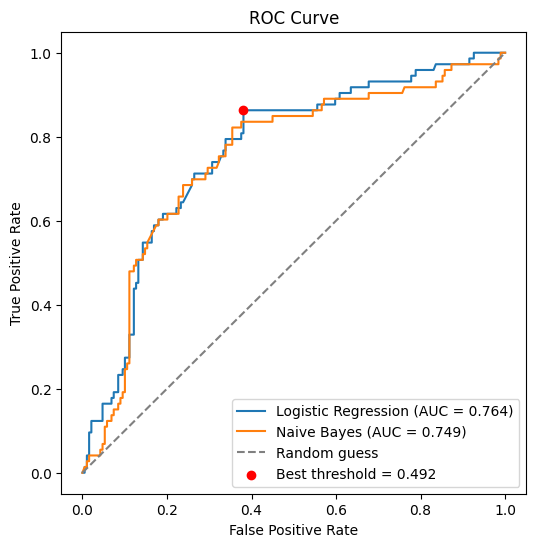

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

# 확률값 뽑기
y_prob_logistic = model.predict_proba(X_test)
y_prob_nb = nb.predict_proba(X_test)[:, 1]

# ROC curve 좌표 + threshold 값들 계산
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_prob_logistic)
fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_test, y_prob_nb)

# AUC
auc_log = roc_auc_score(y_test, y_prob_logistic)
auc_nb = roc_auc_score(y_test, y_prob_nb)

# 최적 threshold 찾기 (logistic 기준)
j_scores = tpr_log - fpr_log
best_idx = np.argmax(j_scores)
best_threshold = thresholds_log[best_idx]

print(f"최적 threshold: {best_threshold:.3f}")
print(f"최저ㄱ일때 FPR={fpr_log[best_idx]:.3f}, TPR(recall)={tpr_log[best_idx]:.3f}")

# 그래프
plt.figure(figsize=(6,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random guess")
plt.scatter(fpr_log[best_idx], tpr_log[best_idx], color="red", zorder=5,
            label=f"Best threshold = {best_threshold:.3f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### logistic regression vs naive bayes

In [ ]:
logistic_acc = accuracy_score(y_test, y_pred)
bayes_acc = accuracy_score(y_test, pred)

print("Logistic Regression :", logistic_acc)
print("Naive Bayes :", bayes_acc)

Logistic Regression : 0.7290076335877863
Naive Bayes : 0.7480916030534351


Accuracy

* Logistic Regression : 약 73%
* Naive Bayes : 약 75%

두 모델 성능이 비슷하고, 둘 다 생존자(class 1)를 잘 못 맞추는 문제가 공통적으로 있음


## 개선할 것

이 모델을 실제 의사결정( 예를 들어 구조 우선순위) 에 활용한다면 FN(생존자를 사망자로 예측하는것)이 제일 치명적이므로 recall을 우선지표로 삼아야함

현재 class 1의 recall(0.33)이 낮아 개선이 필요함
###threshold 낮추기
지금 0.5로 자르고 있는데 roc curve확인해 보니까 0.4정도로 낮추면 recall(TPR)이 올라감(근데 precision은 좀 떨어질것)



